# 🖥️ Reto de nivel Python — TecnoStore

**Datogami · Evaluación de nivel**

¡Bienvenido/a! Este notebook evalúa tu nivel de Python para análisis de datos.
Rellena las celdas marcadas con `# TODO`. Hay pistas en cada apartado y teoría
antes de cada bloque. No busques la respuesta perfecta: buscamos tu **criterio**.

## 🎬 Contexto

Trabajas como analista de datos en **TecnoStore**, una empresa de venta de
ordenadores y componentes. El equipo de sistemas te pasa el inventario en
bruto (`inventario_tecnostore.csv`) y te pide tres cosas:

1. **Limpiar** los datos (vienen sucios de verdad).
2. Sacar unas **estadísticas** de negocio.
3. Preparar unas **visualizaciones** para la reunión.

El reto va de **más fácil a más difícil**. ¡Vamos!

In [1]:
# TODO: importa pandas como pd, numpy como np y matplotlib.pyplot como plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

---
# PARTE 0 · Carga y primera exploración

Antes de tocar nada, **mira** los datos. Nunca limpies a ciegas.

In [2]:
# TODO: carga el CSV 'inventario_tecnostore.csv' en un DataFrame llamado df
# Pista: pd.read_csv(...)
df = pd.read_csv("inventario_tecnostore.csv")

# TODO: muestra las dimensiones (filas, columnas) y las primeras filas
df.head()


,id_producto,modelo,categoria,marca,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta,descatalogado
0,P0038,MSI SOB-395,Sobremesa,MSI,1083.04,"1542,57 €",39,117,NaN,12.0,2024-06-21,0
1,P0055,MSI SOB-497,Sobremesa,MSI,1430.34,"1727,93",29,473,3.3,24.0,2022-04-18,no
2,P0145,Logitech PER-517,Periférico,Logitech,16189.00,"216,61",99,238,4.8,24.0,2019-06-16,no
3,P0064,MSI SOB-990,Sobremesa,MSI,694.75,"845,07 €",63,208,5.0,36.0,2020-11-22,No
4,P0120,Samsung MON-504,monitor,Samsung,669.54,"861,76",56,277,4.2,12.0,2022-01-27,no


In [3]:
# TODO: usa .info() para ver tipos y nulos por columna.
# Fíjate en las columnas 'object' que deberían ser numéricas.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_producto        232 non-null    str    
 1   modelo             232 non-null    str    
 2   categoria          232 non-null    str    
 3   marca              232 non-null    str    
 4   coste_eur          232 non-null    float64
 5   precio_eur         232 non-null    str    
 6   stock              224 non-null    str    
 7   unidades_vendidas  232 non-null    int64  
 8   valoracion         205 non-null    float64
 9   garantia_meses     219 non-null    float64
 10  fecha_alta         232 non-null    str    
 11  descatalogado      232 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 21.9 KB


In [4]:
# TODO: usa describe(include="all") para un resumen de TODAS las columnas
df.describe(include="all")

,id_producto,modelo,categoria,marca,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta,descatalogado
count,232,232,232,232,232.000000,232,224,232.000000,205.000000,219.000000,232,232
unique,220,220,21,33,NaN,220,109,NaN,NaN,NaN,211,8
top,P0064,MSI SOB-990,COMPONENTE,Dell,NaN,"845,07 €",63,NaN,NaN,NaN,2021-02-16,no
freq,2,2,21,28,NaN,2,5,NaN,NaN,NaN,3,55
mean,NaN,NaN,NaN,NaN,2149.899698,NaN,NaN,248.939655,4.059512,24.164384,NaN,NaN
std,NaN,NaN,NaN,NaN,8743.355115,NaN,NaN,149.802484,4.516568,10.051720,NaN,NaN
min,NaN,NaN,NaN,NaN,23.270000,NaN,NaN,2.000000,-3.900000,12.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,293.790000,NaN,NaN,110.000000,3.100000,12.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,676.590000,NaN,NaN,264.500000,3.700000,24.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,1316.857500,NaN,NaN,379.000000,4.400000,36.000000,NaN,NaN


### 🔎 Diagnóstico
Anota aquí (en esta celda de texto) qué problemas has detectado:

- En las columnas he notado que no se esta usando el tipo de datos,id deberia ser tipo int. Modelo,categoria,marca, stock y descatalogado pdoria ser categoricas, las fechas no estan en tipo fecha y hay varios datos numericos como str.
- Tenemos varias ID repetidas ademas de que tenemos datos nulos en costes, las unidades vendidas no nos aparecen.
- Tenemos outliers en los precios, debemos analizar mas adelante si tienen sentido (ofertas y pc de gamma ultra) o si son errores.

---
# PARTE 1 · Limpieza (de fácil a difícil)

## 1.1 · Duplicados

**Teoría:** un duplicado exacto es una fila repetida al 100%. Distorsiona
cualquier conteo o media. `duplicated()` los marca y `drop_duplicates()` los
elimina.

In [5]:
# TODO: cuenta cuántos duplicados exactos hay, elimínalos y resetea el índice.
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 12


In [6]:
df = df.drop_duplicates()
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


## 1.2 · Normalizar texto (categorías y marcas)

**Teoría:** `"Portátil"`, `" portatil "` y `"PORTÁTIL"` son *la misma
categoría* para un humano, pero tres valores distintos para Python. Hay que
**unificar**: quitar espacios (`str.strip`), homogeneizar mayúsculas y mapear
a un valor canónico. Los acentos también cuentan como diferencia.

In [7]:
import unicodedata

def normaliza(texto):
    """minúsculas, sin espacios extra y sin acentos -> para comparar."""
    t = str(texto).strip().lower()
    t = "".join(c for c in unicodedata.normalize("NFKD", t)
                if not unicodedata.combining(c))
    return t

# Te damos el mapa forma_normalizada -> nombre canónico:
mapa_categorias = {
    "portatil":   "Portátil",
    "sobremesa":  "Sobremesa",
    "monitor":    "Monitor",
    "periferico": "Periférico",
    "componente": "Componente",
}

# TODO: aplica 'normaliza' a df["categoria"] y luego .map(mapa_categorias)

# TODO: quita los espacios sobrantes de df["marca"] con .str.strip()


# TODO: comprueba el resultado con value_counts() y los valores únicos de marca
df["categoria"] = df["categoria"].apply(normaliza).map(mapa_categorias)

# Quita los espacios sobrantes de df["marca"] con .str.strip()
df["marca"] = df["marca"].str.strip()

# Comprueba el resultado
print(df["categoria"].value_counts())
print(df["marca"].unique())

categoria
Portátil      58
Componente    51
Sobremesa     39
Monitor       37
Periférico    35
Name: count, dtype: int64
<StringArray>
[      'MSI',  'Logitech',   'Samsung',    'Nvidia',        'HP',      'Dell',
    'Lenovo',     'Apple',     'Intel',  'Kingston',   'Corsair',      'Acer',
      'BenQ',     'Razer',      'Asus',       'AMD',        'LG', 'Microsoft']
Length: 18, dtype: str


## 1.3 · Convertir `precio_eur` de texto a número

**Teoría:** el precio viene como `"1.542,57 €"`: con símbolo de euro, espacios
y **coma** como separador decimal. Para convertirlo a `float` hay que limpiar
el string: quitar `€` y espacios, y cambiar la coma por punto.

In [8]:
def limpia_precio(valor):
    # quita "€" y espacios, cambia "," por "." y devuelve un float
    v = str(valor).replace("€", "").strip()
    v = v.replace(".", "")   # quita el punto de los miles
    v = v.replace(",", ".")  # cambia la coma decimal por punto
    return float(v)

# Aplica limpia_precio a la columna precio_eur y comprueba con describe()
df["precio_eur"] = df["precio_eur"].apply(limpia_precio)
print(df["precio_eur"].describe())

count     220.000000
mean      990.793227
std       785.862282
min        29.950000
25%       274.325000
50%       842.155000
75%      1513.730000
max      3212.910000
Name: precio_eur, dtype: float64


## 1.4 · Convertir `stock` y `garantia_meses` a numérico

**Teoría:** `stock` mezcla números con textos como `"desconocido"`, `"N/A"`,
`"-"` o vacíos. `pd.to_numeric(..., errors="coerce")` convierte lo que puede a
número y pone `NaN` en lo que no puede. Así aislamos los missings reales.

In [9]:
df["stock"] = pd.to_numeric(df["stock"], errors="coerce")
df["garantia_meses"] = pd.to_numeric(df["garantia_meses"], errors="coerce")

# Imprime cuántos nulos quedan en cada una
print(df["stock"].isna().sum())
print(df["garantia_meses"].isna().sum())

15
12


## 1.5 · Gestionar errores y valores imposibles

**Teoría:** no todo error es un nulo. A veces el dato *existe* pero es
**imposible** según las reglas de negocio. Detéctalos con criterio:

- **Stock negativo** → no existe → conviértelo en `NaN`.
- **Valoración fuera de [0, 5]** → la escala es 0 a 5 → fuera de ahí, `NaN`.
- **Coste > precio de venta** → venderíamos a pérdida; es un error de tecleo
  (un cero de más). Corrígelo dividiendo entre 100.

In [10]:
# stock negativo -> NaN
df.loc[df["stock"] < 0, "stock"] = np.nan

# valoración < 0 o > 5 -> NaN
df.loc[(df["valoracion"] < 0) | (df["valoracion"] > 5), "valoracion"] = np.nan

# donde coste_eur > precio_eur, divide coste_eur entre 100
# Pista: primero crea una máscara booleana y cuéntala para ver cuántos son
mask_error_tecleo = df["coste_eur"] > df["precio_eur"]
print(mask_error_tecleo.sum())

df.loc[mask_error_tecleo, "coste_eur"] = df.loc[mask_error_tecleo, "coste_eur"] / 100

10


## 1.6 · Imputar los missings

**Teoría:** una vez aislados los nulos, decide qué hacer. Eliminar filas no
siempre es buena idea (pierdes información). Aquí **imputamos**:

- `valoracion` → mediana **por categoría** (más justo que una global).
- `stock` → mediana global (redondeada a entero).
- `garantia_meses` → la moda (el valor más frecuente).

In [11]:
# TODO: imputa valoracion con la mediana POR categoría
# Pista: df.groupby("categoria")["valoracion"].transform("median")
df["valoracion"] = df["valoracion"].fillna(
    df.groupby("categoria")["valoracion"].transform("median"))


# TODO: imputa stock con la mediana global (entero)
df["stock"] = df["stock"].fillna(round(df["stock"].median()))


# TODO: imputa garantia_meses con la moda -> .mode()[0]
df["garantia_meses"] = df["garantia_meses"].fillna(round(df["garantia_meses"].mode()[0]))


# TODO: comprueba que no quedan nulos con df.isna().sum()
df.isna().sum()

id_producto          0
modelo               0
categoria            0
marca                0
coste_eur            0
precio_eur           0
stock                0
unidades_vendidas    0
valoracion           0
garantia_meses       0
fecha_alta           0
descatalogado        0
dtype: int64

## 1.7 · Normalizar `descatalogado` a booleano y FILTRAR

**Teoría:** `descatalogado` viene como `"Sí"`, `"SI"`, `"true"`, `"1"`,
`"No"`, `"false"`... Conviértelo a `True/False` real y **filtra**: un producto
descatalogado ya no se vende, así que fuera del análisis.

In [12]:
valores_true = {"sí", "si", "true", "1"}

# TODO: convierte descatalogado a booleano (usa la función 'normaliza' y el set)
df["descatalogado"] = df["descatalogado"].apply(lambda x: normaliza(x) in valores_true)


# TODO: quédate solo con los productos NO descatalogados y elimina la columna
df = df[df["descatalogado"] == False].drop(columns="descatalogado")

## 1.8 · Tipos finales (fecha)

**Teoría:** `fecha_alta` es texto. Conviértela a `datetime` para poder operar
con fechas (año, antigüedad, etc.).

In [13]:
# TODO: convierte fecha_alta a datetime con pd.to_datetime(..., errors="coerce")
df["fecha_alta"] = pd.to_datetime(df["fecha_alta"], errors="coerce")

# muestra df.info() para confirmar los tipos finales
df.info()


<class 'pandas.DataFrame'>
Index: 189 entries, 0 to 231
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_producto        189 non-null    str           
 1   modelo             189 non-null    str           
 2   categoria          189 non-null    str           
 3   marca              189 non-null    str           
 4   coste_eur          189 non-null    float64       
 5   precio_eur         189 non-null    float64       
 6   stock              189 non-null    float64       
 7   unidades_vendidas  189 non-null    int64         
 8   valoracion         189 non-null    float64       
 9   garantia_meses     189 non-null    float64       
 10  fecha_alta         189 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(5), int64(1), str(4)
memory usage: 17.7 KB


✅ Si has llegado hasta aquí con la base limpia (sin nulos, tipos correctos,
categorías unificadas y solo catálogo activo), la parte más dura ya está.

---
# PARTE 2 · Estadísticas de negocio

## 2.1 · Resumen numérico general

In [14]:
# TODO: muestra describe() de las columnas numéricas
df.describe()

,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189
mean,704.881852,957.228571,59.328042,237.714286,3.739418,24.825397,2021-10-31 11:25:42.857142
min,23.270000,29.950000,0.000000,6.000000,2.500000,12.000000,2019-01-08 00:00:00
25%,194.750000,246.650000,36.000000,98.000000,3.300000,12.000000,2020-08-09 00:00:00
50%,595.440000,818.680000,56.000000,227.000000,3.700000,24.000000,2021-08-25 00:00:00
75%,1042.490000,1494.410000,89.000000,378.000000,4.200000,36.000000,2022-12-25 00:00:00
max,2085.120000,3212.910000,119.000000,499.000000,5.000000,36.000000,2024-12-20 00:00:00
std,553.445343,767.398019,32.717168,149.556411,0.682041,9.905736,NaN


## 2.2 · Métricas derivadas

**Teoría:** el valor no está solo en las columnas que te dan, sino en las que
**construyes**. Crea:
- `margen_eur` = precio − coste
- `margen_pct` = margen / precio × 100
- `ingresos_eur` = precio × unidades vendidas

In [17]:
# TODO: crea las tres columnas nuevas
df["margen_eur"] = df["precio_eur"] - df["coste_eur"]
df["margen_pct"] = df["margen_eur"] / df["precio_eur"] * 100
df["ingresos_eur"] = df["precio_eur"] * df["unidades_vendidas"]
# TODO: muestra modelo, precio, coste, margen_eur, margen_pct e ingresos_eur
df[["modelo", "precio_eur", "coste_eur", "margen_eur", "margen_pct", "ingresos_eur"]]

,modelo,precio_eur,coste_eur,margen_eur,margen_pct,ingresos_eur
0,MSI SOB-395,1542.57,1083.04,459.53,29.789896,180480.69
1,MSI SOB-497,1727.93,1430.34,297.59,17.222341,817310.89
2,Logitech PER-517,216.61,161.89,54.72,25.261992,51553.18
3,MSI SOB-990,845.07,694.75,150.32,17.787876,175774.56
4,Samsung MON-504,861.76,669.54,192.22,22.305514,238707.52
...,...,...,...,...,...,...
227,Intel COM-402,932.22,715.38,216.84,23.260604,284327.10
228,Asus MON-835,551.22,362.10,189.12,34.309350,168673.32
229,Asus MON-900,193.80,156.28,37.52,19.360165,18992.40
230,Nvidia COM-516,860.82,588.96,271.86,31.581515,317642.58


## 2.3 · Agregación por categoría

**Teoría:** `groupby` parte los datos por grupos y aplica una función a cada
uno. Con `.agg()` calculas varias métricas de golpe.

In [18]:
# TODO: agrupa por categoría y calcula: nº productos, precio medio, stock total,
# valoración media e ingresos totales. Ordena por ingresos de mayor a menor.
# Pista: df.groupby("categoria").agg(nombre=("columna", "funcion"), ...)
resumen_categoria = df.groupby("categoria").agg(
    n_productos=("modelo", "count"),
    precio_medio=("precio_eur", "mean"),
    stock_total=("stock", "sum"),
    valoracion_media=("valoracion", "mean"),
    ingresos_totales=("ingresos_eur", "sum")
).sort_values("ingresos_totales", ascending=False)

resumen_categoria

,n_productos,precio_medio,stock_total,valoracion_media,ingresos_totales
categoria,,,,,
Portátil,51,1503.721569,3203.0,3.721569,15969828.99
Sobremesa,31,1860.911290,1844.0,3.732258,13102335.47
Componente,42,571.549762,2189.0,3.601190,6419641.55
Monitor,32,561.204375,1891.0,3.831250,4806072.51
Periférico,33,138.621818,2086.0,3.860606,1007518.04


## 2.4 · Rankings

In [19]:
# TODO: obtén el TOP 10 de productos por ingresos (usa nlargest)
top10_ingresos = df.nlargest(10, "ingresos_eur")
top10_ingresos

,id_producto,modelo,categoria,marca,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta,margen_eur,margen_pct,ingresos_eur
207,P0040,Lenovo SOB-941,Sobremesa,Lenovo,1949.29,2344.69,83.0,476,2.7,36.0,2022-02-15,395.40,16.863637,1116072.44
32,P0010,Lenovo SOB-120,Sobremesa,Lenovo,1402.66,2052.88,79.0,498,3.5,24.0,2020-03-10,650.22,31.673551,1022334.24
17,P0096,Acer POR-906,Portátil,Acer,1788.90,2060.10,60.0,462,5.0,12.0,2021-02-16,271.20,13.164409,951766.20
120,P0012,Dell SOB-729,Sobremesa,Dell,1534.51,1986.77,36.0,479,2.8,36.0,2021-11-14,452.26,22.763581,951662.83
49,P0111,HP POR-684,Portátil,HP,1721.08,2062.30,27.0,448,2.8,24.0,2020-08-05,341.22,16.545604,923910.40
14,P0214,Dell SOB-548,Sobremesa,Dell,1737.23,2162.55,52.0,422,3.9,36.0,2024-06-15,425.32,19.667522,912596.10
116,P0026,Apple POR-370,Portátil,Apple,1415.80,2046.67,96.0,412,2.8,12.0,2019-05-27,630.87,30.824217,843228.04
165,P0209,Lenovo POR-943,Portátil,Lenovo,1566.79,2165.45,10.0,387,4.1,24.0,2024-06-15,598.66,27.645986,838029.15
1,P0055,MSI SOB-497,Sobremesa,MSI,1430.34,1727.93,29.0,473,3.3,24.0,2022-04-18,297.59,17.222341,817310.89
134,P0121,Asus SOB-760,Sobremesa,Asus,1749.31,2705.70,54.0,265,4.1,12.0,2020-09-10,956.39,35.347230,717010.50


In [20]:
# TODO: calcula los ingresos totales por marca, ordenados de mayor a menor
ingresos_por_marca = df.groupby("marca")["ingresos_eur"].sum().sort_values(ascending=False)
ingresos_por_marca

marca
Dell         7611716.30
Lenovo       6302555.84
HP           4102854.50
Apple        3810989.60
Intel        3490313.54
MSI          3421067.33
Asus         3005519.57
Acer         2472300.47
Samsung      1853984.65
Nvidia       1441872.94
BenQ          766925.59
Kingston      726752.21
LG            680600.00
AMD           562056.74
Razer         340665.66
Corsair       299932.53
Logitech      273640.71
Microsoft     141648.38
Name: ingresos_eur, dtype: float64

## 2.5 · Correlaciones

**Teoría:** la correlación mide si dos variables se mueven juntas (de −1 a 1).
Ojo: correlación **no** implica causalidad.

In [21]:
num_cols = ["coste_eur", "precio_eur", "stock", "unidades_vendidas",
            "valoracion", "margen_pct", "ingresos_eur"]

# TODO: calcula la matriz de correlación de num_cols con .corr()
matriz_corr = df[num_cols].corr()
matriz_corr

,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,margen_pct,ingresos_eur
coste_eur,1.000000,0.989103,0.026732,-0.058293,-0.081853,0.074823,0.666791
precio_eur,0.989103,1.000000,0.028072,-0.078834,-0.068876,0.190529,0.638892
stock,0.026732,0.028072,1.000000,-0.055373,-0.022298,0.019738,-0.031850
unidades_vendidas,-0.058293,-0.078834,-0.055373,1.000000,-0.175310,-0.070583,0.545559
valoracion,-0.081853,-0.068876,-0.022298,-0.175310,1.000000,0.060205,-0.117598
margen_pct,0.074823,0.190529,0.019738,-0.070583,0.060205,1.000000,0.020954
ingresos_eur,0.666791,0.638892,-0.031850,0.545559,-0.117598,0.020954,1.000000


---
# PARTE 3 · Visualización (de fácil a difícil)

## 3.1 · Histograma: distribución de precios

**Teoría:** un histograma muestra cómo se reparten los valores de UNA variable
numérica. Útil para ver concentración, sesgo o colas.

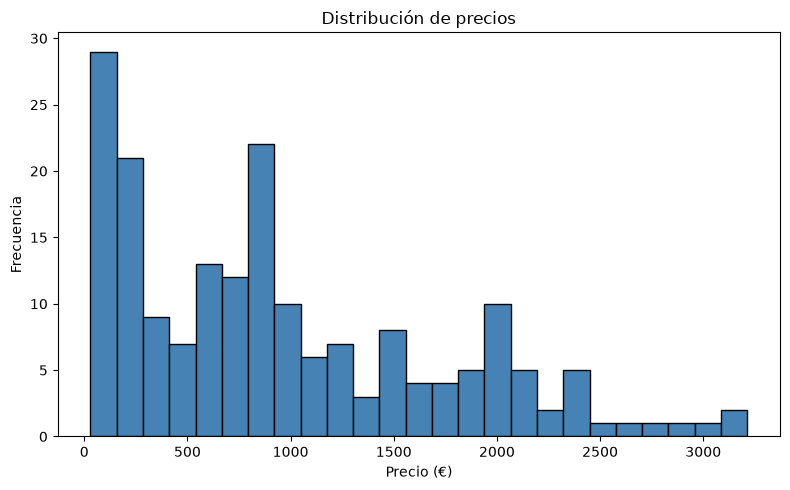

In [22]:
# TODO: haz un histograma de precio_eur (título, ejes y unos 25 bins)
import matplotlib.pyplot as plt

# haz un histograma de precio_eur (título, ejes y unos 25 bins)
plt.figure(figsize=(8, 5))
plt.hist(df["precio_eur"], bins=25, color="steelblue", edgecolor="black")
plt.title("Distribución de precios")
plt.xlabel("Precio (€)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 3.2 · Barras: precio medio por categoría

**Teoría:** el gráfico de barras compara una métrica entre categorías.

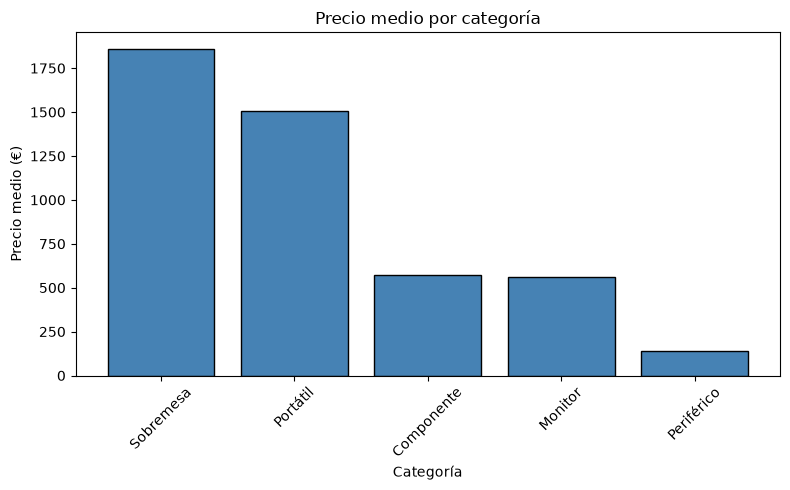

In [23]:
# TODO: calcula el precio medio por categoría y represéntalo con plt.bar
# calcula el precio medio por categoría y represéntalo con plt.bar
precio_medio_categoria = df.groupby("categoria")["precio_eur"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(precio_medio_categoria.index, precio_medio_categoria.values, color="steelblue", edgecolor="black")
plt.title("Precio medio por categoría")
plt.xlabel("Categoría")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.3 · Boxplot: dispersión del precio por categoría

**Teoría:** el boxplot resume mediana, cuartiles y outliers. Ideal para
comparar la *dispersión* entre grupos, no solo la media.

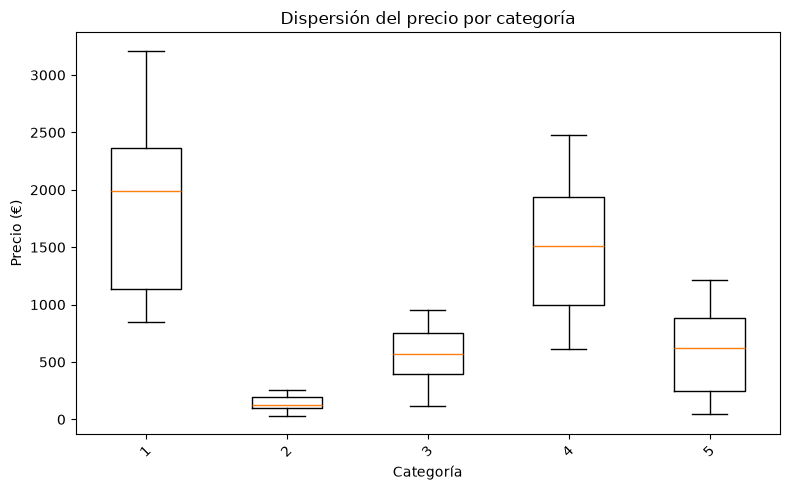

In [26]:
# TODO: crea una lista con los precios de cada categoría y pásala a plt.boxplot
# Pista: [df.loc[df["categoria"]==c, "precio_eur"] for c in df["categoria"].unique()]
# crea una lista con los precios de cada categoría y pásala a plt.boxplot

categorias_unicas = df["categoria"].unique()
datos_boxplot = [df.loc[df["categoria"] == c, "precio_eur"] for c in categorias_unicas]

plt.figure(figsize=(8, 5))
plt.boxplot(datos_boxplot, label=categorias_unicas)
plt.title("Dispersión del precio por categoría")
plt.xlabel("Categoría")
plt.ylabel("Precio (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.4 · Scatter: ¿relación entre valoración y unidades vendidas?

**Teoría:** el scatter enfrenta DOS variables numéricas para ver si hay
relación. Colorea por categoría para añadir una tercera dimensión.

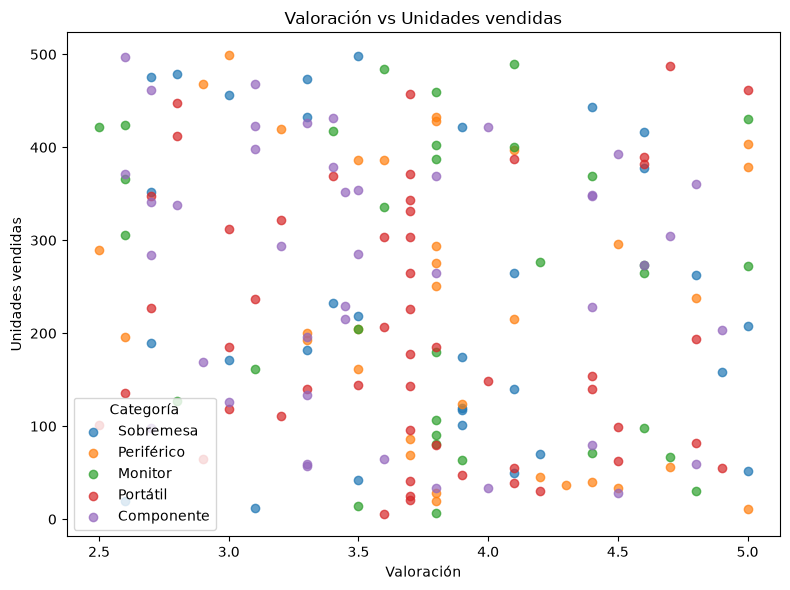

In [27]:
# TODO: haz un scatter valoracion (x) vs unidades_vendidas (y),
# un color por categoría, con leyenda
import matplotlib.pyplot as plt

# haz un scatter valoracion (x) vs unidades_vendidas (y),
# un color por categoría, con leyenda
plt.figure(figsize=(8, 6))

for categoria in df["categoria"].unique():
    subset = df[df["categoria"] == categoria]
    plt.scatter(subset["valoracion"], subset["unidades_vendidas"], label=categoria, alpha=0.7)

plt.title("Valoración vs Unidades vendidas")
plt.xlabel("Valoración")
plt.ylabel("Unidades vendidas")
plt.legend(title="Categoría")
plt.tight_layout()
plt.show()

## 3.5 · Heatmap de correlaciones (nivel avanzado)

**Teoría:** un mapa de calor de la matriz de correlación permite ver de un
vistazo qué variables se relacionan. Puedes hacerlo solo con matplotlib
(`plt.imshow`) sin librerías extra.

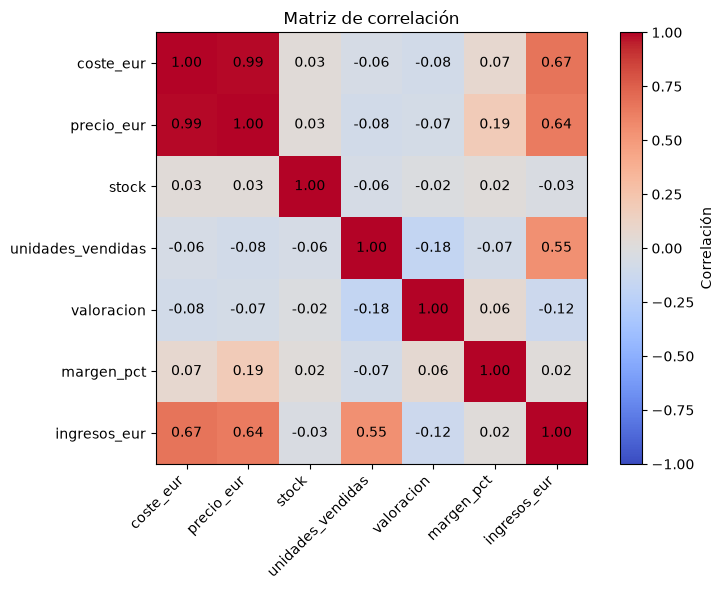

In [28]:
# TODO (reto): dibuja la matriz de correlación como heatmap con imshow,
# etiquetas en los ejes y el valor numérico en cada celda.
# dibuja la matriz de correlación como heatmap con imshow,
# etiquetas en los ejes y el valor numérico en cada celda.
matriz_corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(matriz_corr, cmap="coolwarm", vmin=-1, vmax=1)

# etiquetas en los ejes
ax.set_xticks(range(len(matriz_corr.columns)))
ax.set_yticks(range(len(matriz_corr.columns)))
ax.set_xticklabels(matriz_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(matriz_corr.columns)

# valor numérico en cada celda
for i in range(len(matriz_corr.columns)):
    for j in range(len(matriz_corr.columns)):
        ax.text(j, i, f"{matriz_corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(cax, label="Correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 3.6 · Reto final: ingresos por marca (barras horizontales ordenadas)

**Teoría:** combina agregación + orden + visualización. Las barras
horizontales van muy bien cuando hay muchas etiquetas o son largas.

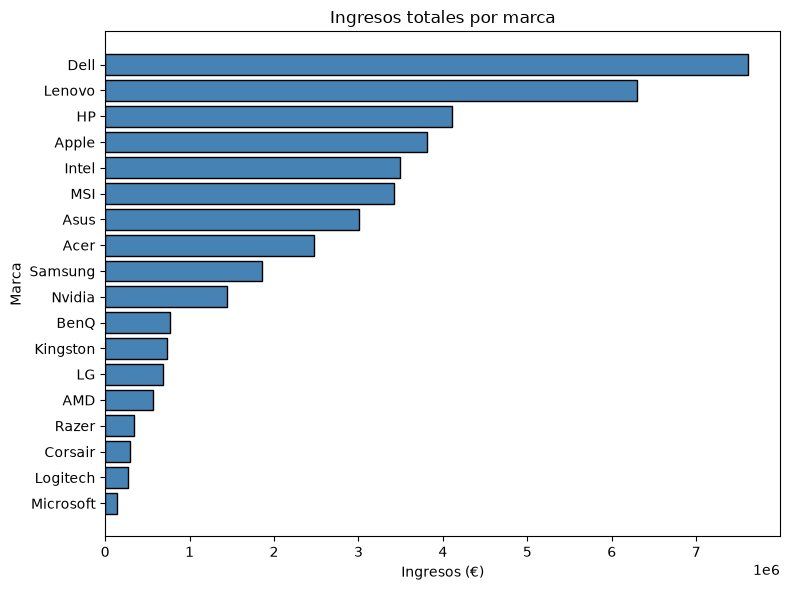

In [29]:
# TODO (reto): ingresos totales por marca en barras horizontales, ordenadas
ingresos_por_marca = df.groupby("marca")["ingresos_eur"].sum().sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(ingresos_por_marca.index, ingresos_por_marca.values, color="steelblue", edgecolor="black")
plt.title("Ingresos totales por marca")
plt.xlabel("Ingresos (€)")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

---
## 🏁 Cierre

Has recorrido el flujo completo de un analista: **cargar → limpiar → analizar
→ visualizar**. En un caso real, la limpieza suele ser el 70–80% del trabajo.

**¿Dudas o quieres feedback?** Comparte tu notebook en la comunidad de Skool. 🚀

Comentario:
La actividad me parecio muy buena, mas que nada porque nos describe el paso a paso de lo que debemos hacer, personalmente utilice Claude para resolver algunos problemas pero considero que aun asi la actividad es muy buena puesto que al final de cuentas iremos aprendiendo el proceso y llegara el punto donde no necesite claude para un simple comando.